# Stacked-Uptrend Screener: A Momentum Screening Tutorial

*ScientiaLab — open financial intelligence*

This notebook teaches the core leadership screen used in Scientia Capital
Management's weekly Nasdaq-100 reports: finding stocks in a **stacked
moving-average uptrend**, confirmed by momentum and mean-reversion filters.

**The four checks**

1. **Stacked uptrend** — `SMA50 > SMA100 > SMA200` (short-term trend leading medium leading long)
2. **Bullish MACD** — MACD line above its signal line (momentum confirmation)
3. **RSI in a healthy band** — `45 <= RSI(14) <= 75` (trending, not yet overbought/exhausted)
4. **Near the 50-day average** — price within 2x ATR(14) of the 50-day SMA (a reasonable entry, not chasing an extended move)

A ticker's **score** is how many of the four checks it passes (0–4). This is
the same rubric behind the "leadership" tables in Scientia's weekly reports —
built here from scratch with pandas so anyone can run it, inspect it, and
adapt it.

> **Educational tool only.** This notebook does not constitute financial
> advice. Sample data below is synthetic, for illustration only — see the
> "Using real market data" section to plug in live prices.


## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)


## 2. Sample data

The tickers below are the same ten names covered in the Aug 13, 2026 weekly
report (semiconductors and hardware names from the Nasdaq-100). To keep this
notebook runnable anywhere — no API key, no internet required — we generate
a synthetic daily close series per ticker with a realistic two-regime drift
(choppy, then trending). Swap this out for real data in one line; see
Section 6.

In [4]:
UNIVERSE = ["MRVL", "MU", "STX", "ARM", "INTC", "ASML", "AMAT", "LRCX", "CSCO", "AVGO"]

def make_sample_prices(ticker, days=420, seed_offset=0):
    """Synthetic daily OHLCV series with a drift regime change, standing in
    for real price history so this notebook runs with zero dependencies on
    an external data source."""
    rs = np.random.default_rng(42 + seed_offset)
    n = days
    regime_split = n - 140  # last ~140 sessions trend up, echoing a leadership setup
    drift = np.concatenate([
        rs.normal(0.0002, 0.012, regime_split),
        rs.normal(0.0032, 0.014, n - regime_split),
    ])
    price = 40 + rs.uniform(0, 60)
    closes = price * np.exp(np.cumsum(drift))
    dates = pd.bdate_range(end=pd.Timestamp("2026-08-13"), periods=n)
    high = closes * (1 + rs.uniform(0.002, 0.014, n))
    low = closes * (1 - rs.uniform(0.002, 0.014, n))
    open_ = closes * (1 + rs.normal(0, 0.004, n))
    volume = rs.integers(1_000_000, 9_000_000, n)
    return pd.DataFrame(
        {"open": open_, "high": high, "low": low, "close": closes, "volume": volume},
        index=dates,
    )

sample = make_sample_prices("MRVL", seed_offset=0)
sample.tail()


,open,high,low,close,volume
2026-08-07,115.047129,116.747632,115.184570,115.862717,2428833
2026-08-10,118.375022,119.294960,117.510444,118.020114,5751930
2026-08-11,120.681763,122.132324,120.228970,120.619706,8231233
2026-08-12,122.043465,121.680897,119.390969,120.889238,3697097
2026-08-13,123.052942,124.610853,122.475568,123.596835,5395948


## 3. Indicators, from scratch

No `ta-lib`, no extra dependencies — just pandas. These four functions cover
everything the screen needs: simple/exponential moving averages, MACD, RSI,
and ATR.

In [6]:
def sma(series, window):
    return series.rolling(window).mean()

def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def macd(series, fast=12, slow=26, signal=9):
    macd_line = ema(series, fast) - ema(series, slow)
    signal_line = ema(macd_line, signal)
    hist = macd_line - signal_line
    return macd_line, signal_line, hist

def rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, adjust=False).mean()
    rs_ = avg_gain / avg_loss
    return 100 - (100 / (1 + rs_))

def atr(df, window=14):
    high, low, close = df["high"], df["low"], df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.ewm(alpha=1 / window, adjust=False).mean()


## 4. The screen

`screen_ticker` computes every indicator, checks the four rules against the
most recent session, and returns a one-row summary plus the full indicator
history (for charting).

In [8]:
def screen_ticker(ticker, seed_offset):
    df = make_sample_prices(ticker, seed_offset=seed_offset)
    close = df["close"]

    df["sma50"] = sma(close, 50)
    df["sma100"] = sma(close, 100)
    df["sma200"] = sma(close, 200)
    macd_line, signal_line, hist = macd(close)
    df["macd"], df["macd_signal"] = macd_line, signal_line
    df["rsi14"] = rsi(close)
    df["atr14"] = atr(df)

    last = df.iloc[-1]

    stacked_uptrend = last["sma50"] > last["sma100"] > last["sma200"]
    bullish_macd = last["macd"] > last["macd_signal"]
    rsi_in_band = 45 <= last["rsi14"] <= 75
    atr_distance = abs(last["close"] - last["sma50"]) / last["atr14"]
    near_50ma = atr_distance <= 2.0

    score = sum([stacked_uptrend, bullish_macd, rsi_in_band, near_50ma])

    summary = {
        "ticker": ticker,
        "close": round(last["close"], 2),
        "sma50": round(last["sma50"], 2),
        "sma100": round(last["sma100"], 2),
        "sma200": round(last["sma200"], 2),
        "stacked_uptrend": stacked_uptrend,
        "bullish_macd": bullish_macd,
        "rsi14": round(last["rsi14"], 1),
        "rsi_in_band": rsi_in_band,
        "atr_distance": round(atr_distance, 2),
        "near_50ma": near_50ma,
        "score": score,
    }
    return summary, df


## 5. Run the screen across the universe

In [10]:
results, frames = [], {}
for i, t in enumerate(UNIVERSE):
    summary, df = screen_ticker(t, seed_offset=i)
    results.append(summary)
    frames[t] = df

results_df = (
    pd.DataFrame(results)
    .sort_values(["score", "ticker"], ascending=[False, True])
    .reset_index(drop=True)
)
results_df


,ticker,close,sma50,sma100,sma200,stacked_uptrend,bullish_macd,rsi14,rsi_in_band,atr_distance,near_50ma,score
0,ARM,77.84,69.38,61.63,53.04,True,True,66.1,True,4.85,False,3
1,CSCO,179.21,173.86,155.72,135.83,True,False,45.8,True,1.42,True,3
2,LRCX,215.48,194.89,181.03,157.13,True,True,71.7,True,5.28,False,3
3,MRVL,123.60,117.85,107.87,91.34,True,True,63.7,True,2.11,False,3
4,MU,119.87,109.36,100.55,83.70,True,True,71.7,True,4.16,False,3
5,AMAT,103.13,86.89,80.18,78.69,True,True,85.3,False,7.97,False,2
6,ASML,117.57,107.49,94.46,81.97,True,False,63.8,True,4.21,False,2
7,AVGO,113.17,104.81,96.61,89.54,True,False,64.0,True,3.91,False,2
8,STX,108.17,93.08,85.93,77.27,True,True,75.6,False,6.30,False,2
9,INTC,93.04,88.43,88.72,89.56,False,False,58.3,True,2.56,False,1


Highest-scoring names are the ones passing the most filters this
session — the same shortlist logic behind the "leadership" section of the
weekly report. On synthetic data the ranking will differ every run you
change the seed; on real data, re-running weekly is exactly how the
Scientia screen stays current.

In [12]:
top_score = results_df["score"].max()
leaders = results_df.loc[results_df["score"] == top_score, "ticker"].tolist()
print(f"Top score this run: {top_score}/4")
print(f"Leaders: {leaders}")


Top score this run: 3/4
Leaders: ['ARM', 'CSCO', 'LRCX', 'MRVL', 'MU']


## 6. Chart the top name

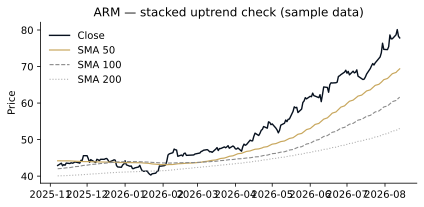

In [14]:
top_ticker = results_df.iloc[0]["ticker"]
plot_df = frames[top_ticker].tail(200)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(plot_df.index, plot_df["close"], label="Close", color="#07111f", linewidth=1.4)
ax.plot(plot_df.index, plot_df["sma50"], label="SMA 50", color="#c8a75d", linewidth=1.2)
ax.plot(plot_df.index, plot_df["sma100"], label="SMA 100", color="#8a8a8a", linewidth=1.1, linestyle="--")
ax.plot(plot_df.index, plot_df["sma200"], label="SMA 200", color="#b0b0b0", linewidth=1.1, linestyle=":")
ax.set_title(f"{top_ticker} — stacked uptrend check (sample data)")
ax.set_ylabel("Price")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 7. Building your own pseudo-OHLC generator

Free real-data APIs are a moving target: `yfinance` scrapes an undocumented
Yahoo endpoint that breaks without notice, and providers that used to be
keyless (like Stooq) have since locked their download endpoints behind a
signup. Rather than chase whichever API happens to work this month, this
section builds a **configurable synthetic OHLCV generator** — useful in its
own right for testing a screen's *logic*, since you control the regime
exactly and know whether the screen should fire.

The screen only depends on a DataFrame with
`open, high, low, close, volume` columns, so any generator that returns one
slots in without changing Sections 3–6.

In [16]:
def generate_ohlc(ticker, days=420, trend="mixed", volatility="normal", seed=0):
    """Configurable synthetic daily OHLCV generator with zero external
    dependencies — no API, no key, no rate limit, never breaks.

    trend: "up", "down", "choppy", or "mixed" (choppy start, trending finish —
           the same shape used by make_sample_prices above)
    volatility: "low", "normal", or "high" (daily return dispersion)
    """
    rs = np.random.default_rng(abs(hash((ticker, seed))) % (2**32))
    n = days
    sigma = {"low": 0.006, "normal": 0.012, "high": 0.024}[volatility]

    if trend == "up":
        mu = np.full(n, 0.0015)
    elif trend == "down":
        mu = np.full(n, -0.0015)
    elif trend == "choppy":
        mu = np.zeros(n)
    else:  # "mixed"
        split = n - n // 3
        mu = np.concatenate([np.full(split, 0.0002), np.full(n - split, 0.0032)])

    drift = rs.normal(mu, sigma)
    price0 = 40 + rs.uniform(0, 60)
    closes = price0 * np.exp(np.cumsum(drift))

    dates = pd.bdate_range(end=pd.Timestamp.today(), periods=n)
    high = closes * (1 + rs.uniform(0.002, 0.014, n))
    low = closes * (1 - rs.uniform(0.002, 0.014, n))
    open_ = closes * (1 + rs.normal(0, 0.004, n))
    volume = rs.integers(1_000_000, 9_000_000, n)

    return pd.DataFrame(
        {"open": open_, "high": high, "low": low, "close": closes, "volume": volume},
        index=dates,
    )


Because you control the regime, you can stress-test the screen
directly — for example, confirming it correctly rejects a deliberate
downtrend rather than just checking it accepts an uptrend:

In [18]:
down_df = generate_ohlc("TEST_DOWN", trend="down", volatility="high", seed=1)
down_df["sma50"] = sma(down_df["close"], 50)
down_df["sma100"] = sma(down_df["close"], 100)
down_df["sma200"] = sma(down_df["close"], 200)
last = down_df.iloc[-1]
print(f"Downtrend stress test — stacked uptrend check: {last['sma50'] > last['sma100'] > last['sma200']}")


Downtrend stress test — stacked uptrend check: False


From there, the natural next steps: widen the universe beyond ten
tickers, tune the RSI band and ATR-distance thresholds, or add sector/
market-cap filters — the same kind of iteration behind each week's Scientia
report. If you'd rather work with live prices, `generate_ohlc` and
`make_sample_prices` are both drop-in replaceable with any data source that
returns the same five columns; just be prepared for free-tier APIs to
require a signup, and for scraping-based ones to occasionally break.


---

**Disclaimer:** This notebook is an educational resource. It illustrates a
screening methodology and does not constitute investment advice, a
recommendation, or an offer to buy or sell any security. Sample data is
synthetic. Always validate any real signal against current data and your
own risk framework before acting on it.

Built and shared by ScientiaLab, the open learning arm of
[Scientia Capital Management](https://www.scientiacapital.co.uk/).
